In [27]:
import numpy as np 
import pandas as pd 

In [28]:
prices = pd.read_excel('Prices.xlsx')
prices.head()



,OPERATING_DATE,HOUR_ENDING,NP15 ($/MWh)
0,2022-03-21,1,45.04
1,2022-03-21,2,43.63
2,2022-03-21,3,43.43
3,2022-03-21,4,43.42
4,2022-03-21,5,46.30


In [29]:
ct_start_fuel = 220
ct_start_cost = 7250

cc_start_fuel = 850   #
cc_start_cost = 16500

# Configuration data
configs = {
    1: {"name": "off"},
    2: {"name": "1 CT", "min_mw": 57, "heat_rate_min": 12.591, "vom": 5},
    3: {"name": "2 CT", "min_mw": 114, "heat_rate_min": 12.591, "vom": 5},
    4: {"name": "1x1", "min_mw": 150, "heat_rate_min": 7.695, "vom": 2.5},
    5: {"name": "2x1", "min_mw": 312, "heat_rate_min": 7.121, "vom": 2.0},
}


In [30]:
# -------------------------
# COMPUTE SU + ML
# -------------------------

results = []

for c in configs:
    
    # --- Startup (SU) ---
    if c == 1:
        su_fuel = 0
        su_cost = 0
    elif c == 2:
        su_fuel = ct_start_fuel
        su_cost = ct_start_cost
    elif c == 3:
        su_fuel = 2 * ct_start_fuel
        su_cost = 2 * ct_start_cost
    elif c == 4:
        su_fuel = cc_start_fuel
        su_cost = cc_start_cost
    elif c == 5:
        su_fuel = cc_start_fuel + ct_start_fuel
        su_cost = cc_start_cost + ct_start_cost

    # --- Minimum Load (ML) ---
    if c == 1:
        ml_fuel = 0
        ml_cost = 0
    else:
        min_mw = configs[c]["min_mw"]
        heat_rate = configs[c]["heat_rate_min"]
        vom = configs[c]["vom"]

        ml_fuel = min_mw * heat_rate
        ml_cost = min_mw * vom

    # store
    results.append({
        "Config": c,
        "Name": configs[c]["name"],
        "SU Fuel (MMBtu/start)": su_fuel,
        "SU Cost ($/start)": su_cost,
        "ML Fuel (MMBtu/hr)": ml_fuel,
        "ML Cost ($/hr)": ml_cost
    })

# -------------------------
# OUTPUT TABLE
# -------------------------

output = pd.DataFrame(results)
output.head()

,Config,Name,SU Fuel (MMBtu/start),SU Cost ($/start),ML Fuel (MMBtu/hr),ML Cost ($/hr)
0,1,off,0,0,0.000,0.0
1,2,1 CT,220,7250,717.687,285.0
2,3,2 CT,440,14500,1435.374,570.0
3,4,1x1,850,16500,1154.250,375.0
4,5,2x1,1070,23750,2221.752,624.0


In [31]:
configs = {
    1: {"name": "OFF", "mw": [0], "heat": [0], "vom": 0},
    
    2: {
        "name": "1 CT",
        "mw": [57, 114, 152, 190],
        "heat": [12.591, 10.642, 10.275, 10.133],
        "vom": 5
    },
    
    3: {
        "name": "2 CT",
        "mw": [114, 228, 304, 380],
        "heat": [12.591, 10.642, 10.275, 10.133],
        "vom": 5
    },
    
    4: {
        "name": "1x1",
        "mw": [150, 204, 272, 340],
        "heat": [7.695, 7.358, 7.149, 7.048],
        "vom": 2.5
    },
    
    5: {
        "name": "2x1",
        "mw": [312, 366, 488, 610],
        "heat": [7.121, 6.999, 6.839, 6.762],
        "vom": 2.0
    }
}

# -------------------------
# 3. Compute bid curves
# -------------------------
rows = []

for config_id, data in configs.items():
    for mw, heat in zip(data["mw"], data["heat"]):
        
        # OFF case
        if config_id == 1:
            price = 0
        else:
            price = heat * gas_price + data["vom"]
        
        rows.append({
            "Config": config_id,
            "Config_Name": data["name"],
            "MW": mw,
            "Price ($/MWh)": round(price, 3)
        })

bid_df = pd.DataFrame(rows)

bid_df

,Config,Config_Name,MW,Price ($/MWh)
0,1,OFF,0,0.000
1,2,1 CT,57,67.955
2,2,1 CT,114,58.210
3,2,1 CT,152,56.375
4,2,1 CT,190,55.665
5,3,2 CT,114,67.955
6,3,2 CT,228,58.210
7,3,2 CT,304,56.375
8,3,2 CT,380,55.665
9,4,1x1,150,40.975


In [32]:
# =============================================================================
# TASK 2C: CCGT MILP Optimization using Gurobi
# =============================================================================

import os
os.environ["GRB_LICENSE_FILE"] = os.path.abspath("gurobi.lic")

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

# --- Parameters (simplified per spec) ---
gas_price = 5  # $/MMBtu
T = 168  # hours (March 21-27, 2022)

# Config: 0=OFF, 1=1 CT, 2=2 CT, 3=1x1, 4=2x1
CONFIG_NAMES = ["OFF", "1 CT", "2 CT", "1x1", "2x1"]
MIN_MW = [0, 57, 114, 150, 312]
MAX_MW = [0, 190, 380, 340, 610]
vom = [0, 5, 5, 2.5, 2.0]
startup_cost = [0, 7250, 14500, 16500, 23750]
heat_rate = [0, 10.275, 10.275, 7.149, 6.839]  # at 80% load

# Get electricity prices (ensure we have 168 hours)
price_col = [c for c in prices.columns if "NP15" in c][0]
price = prices[price_col].values[:T]

# --- Build Gurobi model ---
model = gp.Model("CCGT")
model.setParam("OutputFlag", 0)

C = range(5)
T_range = range(T)

# Decision variables
u = model.addVars(C, T_range, vtype=GRB.BINARY, name="u")
p = model.addVars(C, T_range, vtype=GRB.CONTINUOUS, lb=0, name="p")
v = model.addVars(C, T_range, vtype=GRB.BINARY, name="v")

# One configuration per hour: sum_c u[c,t] == 1
for t in T_range:
    model.addConstr(gp.quicksum(u[c, t] for c in C) == 1)

# Generation bounds: min_MW[c]*u[c,t] <= p[c,t] <= max_MW[c]*u[c,t]
for c in C:
    for t in T_range:
        model.addConstr(p[c, t] >= MIN_MW[c] * u[c, t])
        model.addConstr(p[c, t] <= MAX_MW[c] * u[c, t])

# Startup logic: v[c,t] >= u[c,t] - u[c,t-1], v[c,t] <= u[c,t] (startup only if ON)
for c in C:
    for t in T_range:
        if t == 0:
            model.addConstr(v[c, t] == u[c, t])
        else:
            model.addConstr(v[c, t] >= u[c, t] - u[c, t - 1])
            model.addConstr(v[c, t] <= u[c, t])

# Objective: maximize profit = Revenue - Cost
revenue = gp.quicksum(price[t] * gp.quicksum(p[c, t] for c in C) for t in T_range)
cost = gp.quicksum(
    (heat_rate[c] * gas_price + vom[c]) * p[c, t] + startup_cost[c] * v[c, t]
    for c in C for t in T_range
)
model.setObjective(revenue - cost, GRB.MAXIMIZE)

# Solve
model.optimize()

# Extract solution (required for downstream CSV, plots, metrics)
u_val = model.getAttr("X", u)
p_val = model.getAttr("X", p)
v_val = model.getAttr("X", v)

# Convert to list-of-lists for downstream use
u_val = [[u_val[c, t] for t in T_range] for c in C]
p_val = [[p_val[c, t] for t in T_range] for c in C]
v_val = [[v_val[c, t] for t in T_range] for c in C]

# Build results arrays for each hour
config_active = []
mw_gen = []
for t in T_range:
    for c in C:
        if u_val[c][t] > 0.5:
            config_active.append(CONFIG_NAMES[c])
            mw_gen.append(p_val[c][t])
            break

In [33]:
# --- OUTPUT 1: Create CCGT_CAISO.csv ---
output_df = prices[["OPERATING_DATE", "HOUR_ENDING"]].iloc[:T].copy()
output_df["PRICE_ELECTRIC"] = price
output_df["CONFIGURATION_ACTIVE"] = config_active
output_df["MW_GENERATION"] = mw_gen

output_df.to_csv("CCGT_CAISO.csv", index=False)

# --- OUTPUT 2: Print first 12 rows ---
print("First 12 rows of CCGT_CAISO.csv:")
print(output_df.head(12).to_string())

First 12 rows of CCGT_CAISO.csv:
   OPERATING_DATE  HOUR_ENDING  PRICE_ELECTRIC CONFIGURATION_ACTIVE  MW_GENERATION
0      2022-03-21            1           45.04                  2x1          610.0
1      2022-03-21            2           43.63                  2x1          610.0
2      2022-03-21            3           43.43                  2x1          610.0
3      2022-03-21            4           43.42                  2x1          610.0
4      2022-03-21            5           46.30                  2x1          610.0
5      2022-03-21            6           55.50                  2x1          610.0
6      2022-03-21            7           76.70                  2x1          610.0
7      2022-03-21            8           77.29                  2x1          610.0
8      2022-03-21            9           51.19                  2x1          610.0
9      2022-03-21           10           46.89                  2x1          610.0
10     2022-03-21           11           43.54        

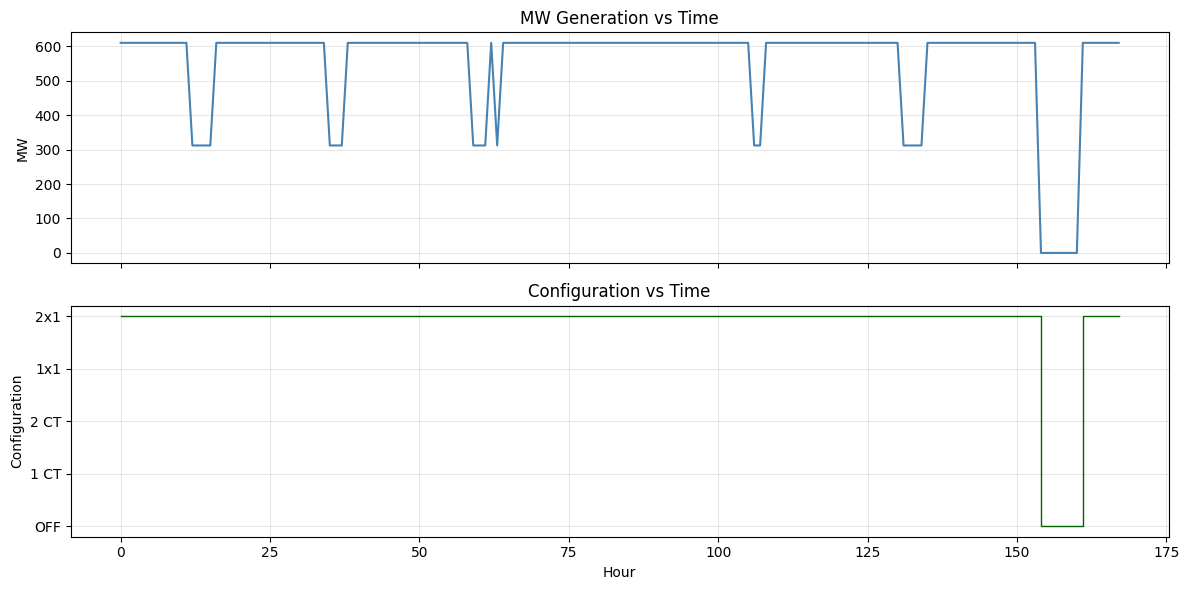

In [34]:
# --- OUTPUT 3: Plots ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot 1: MW vs time
axes[0].plot(range(T), mw_gen, color="steelblue", linewidth=1.5)
axes[0].set_ylabel("MW")
axes[0].set_title("MW Generation vs Time")
axes[0].grid(True, alpha=0.3)

# Plot 2: Configuration vs time (step plot)
config_map = {name: i for i, name in enumerate(CONFIG_NAMES)}
config_nums = [config_map[c] for c in config_active]
axes[1].step(range(T), config_nums, where="post", color="darkgreen", linewidth=1)
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(CONFIG_NAMES)
axes[1].set_ylabel("Configuration")
axes[1].set_xlabel("Hour")
axes[1].set_title("Configuration vs Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# --- OUTPUT 4: Summary metrics ---
total_revenue = sum(price[t] * mw_gen[t] for t in range(T))
total_var_cost = sum(
    (heat_rate[c] * gas_price + vom[c]) * p_val[c][t]
    for c in range(5) for t in range(T)
)
total_startup_cost = sum(startup_cost[c] * v_val[c][t] for c in range(5) for t in range(T))
fuel_costs = sum(
    heat_rate[c] * gas_price * p_val[c][t]
    for c in range(5) for t in range(T)
)
num_starts = sum(int(round(v_val[c][t])) for c in range(5) for t in range(T))
max_capacity = 610  # 2x1 max MW
capacity_factor = 100 * sum(mw_gen) / (max_capacity * T)
gross_margin = (total_revenue - total_var_cost - total_startup_cost) / (max_capacity * 1000)  # $/kW

print("=" * 50)
print("CCGT Optimization Summary")
print("=" * 50)
print(f"Total Revenue ($):        {total_revenue:,.2f}")
print(f"Total Costs ($):          {total_var_cost + total_startup_cost:,.2f}")
print(f"Fuel Costs ($):           {fuel_costs:,.2f}")
print(f"Number of Starts:         {num_starts}")
print(f"Capacity Factor (%):      {capacity_factor:.2f}%")
print(f"Gross Margin ($/kW):      {gross_margin:.4f}")

CCGT Optimization Summary
Total Revenue ($):        5,165,773.30
Total Costs ($):          3,418,847.08
Fuel Costs ($):           3,185,059.08
Number of Starts:         170
Capacity Factor (%):      90.89%
Gross Margin ($/kW):      2.8638
